PHASE 1: Mount, list, load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!ls "/content/drive/MyDrive/Datasets"

import pandas as pd
data_folder = '/content/drive/MyDrive/Datasets/'
df_count_points = pd.read_csv(data_folder + 'count_points.csv', low_memory=False)
df_local_authority = pd.read_csv(data_folder + 'local_authority_traffic.csv', low_memory=False)

print("Count Points:", df_count_points.shape)
print("Local Authority:", df_local_authority.shape)


Mounted at /content/drive
average_annual_daily_flow.csv	mrdb-2018.zip  mrdb-2022.zip
count_points.csv		mrdb-2019.zip  mrdb-2023.zip
local_authority_traffic.csv	mrdb-2020.zip  mrdb-2024.zip
local_authority_traffic.gsheet	mrdb-2021.zip  Processed
Count Points: (46251, 19)
Local Authority: (6560, 8)


Install geospatial libraries

In [ ]:
!pip -q install geopandas pyogrio shapely pyproj rtree folium

Filter to London boroughs (explicit list)

In [ ]:
london_boroughs = [
    'Barnet','Hillingdon','Tower Hamlets','Islington','Southwark','Lewisham','Greenwich',
    'Bexley','Lambeth','Wandsworth','Westminster','Kensington and Chelsea','Hounslow','Brent',
    'Enfield','Hackney','Redbridge','Waltham Forest','Croydon','Camden','Hammersmith and Fulham',
    'Ealing','Haringey','Newham','Barking and Dagenham','City of London','Richmond upon Thames',
    'Bromley','Sutton','Kingston upon Thames','Harrow','Havering','Merton'
]

df_cp_london = df_count_points[df_count_points['local_authority_name'].isin(london_boroughs)].copy()
df_la_london = df_local_authority[df_local_authority['local_authority_name'].isin(london_boroughs)].copy()

print("✅ Local Authority (London):", df_la_london.shape)


✅ Local Authority (London): (1056, 8)


GeoDataFrame for count points (WGS84 for preview)

GeoDataFrame created: (3630, 20)


Text(0.5, 1.0, 'London Count Points – GeoDataFrame Preview')

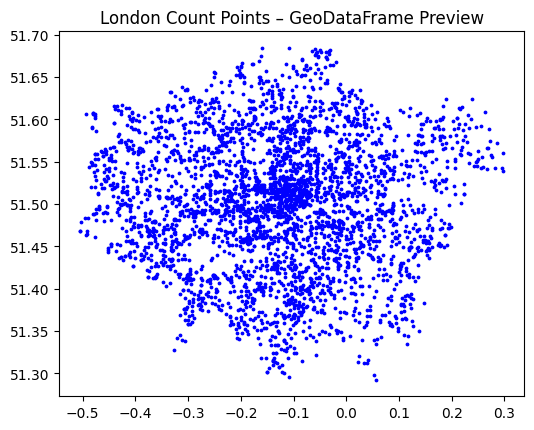

In [ ]:
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

df_cp_london['latitude'] = pd.to_numeric(df_cp_london['latitude'], errors='coerce')
df_cp_london['longitude'] = pd.to_numeric(df_cp_london['longitude'], errors='coerce')
df_cp_london = df_cp_london.dropna(subset=['latitude','longitude'])

geometry = [Point(xy) for xy in zip(df_cp_london['longitude'], df_cp_london['latitude'])]
gdf_cp_london = gpd.GeoDataFrame(df_cp_london, geometry=geometry, crs="EPSG:4326")
print("GeoDataFrame created:", gdf_cp_london.shape)

gdf_cp_london.plot(figsize=(6,6), color='blue', markersize=3)
plt.title('London Count Points – GeoDataFrame Preview')


Load MRDB/MRN, clip to London extent, combine

In [ ]:
import os

mrdb_years = [2018, 2019, 2020, 2021, 2022, 2023, 2024]
mrdb_data = {}
for year in mrdb_years:
    file_path = os.path.join(data_folder, f'mrdb-{year}.zip')
    print(f"Loading MRDB {year}...")
    gdf = gpd.read_file(f"zip://{file_path}")

    # If CRS is missing, check dataset readme; many MRN files are EPSG:27700
    if gdf.crs is None:
        gdf = gdf.set_crs(27700, allow_override=True)  # use only if sure about source CRS
    gdf = gdf.to_crs(4326)  # match points for clipping and preview maps
    gdf['mrdb_year'] = year
    mrdb_data[year] = gdf
    print(f"MRDB {year} loaded:", gdf.shape)

# Clip by buffered bbox from count points
from shapely.geometry import box
minx, miny, maxx, maxy = gdf_cp_london.total_bounds
pad = 0.05  # ~5–6 km buffer around London extent
clip_poly = gpd.GeoDataFrame(geometry=[box(minx-pad, miny-pad, maxx+pad, maxy+pad)], crs=4326)

mrdb_london = {}
for year, gdf in mrdb_data.items():
    g_clip = gdf.clip(clip_poly)
    mrdb_london[year] = g_clip
    print(f"MRDB {year} clipped:", g_clip.shape)

# Combine years
gdf_mrdb_all = gpd.GeoDataFrame(pd.concat(mrdb_london.values(), ignore_index=True), crs=4326)
print("Combined MRDB (London):", gdf_mrdb_all.shape)

Loading MRDB 2018...
MRDB 2018 loaded: (18193, 4)
Loading MRDB 2019...
MRDB 2019 loaded: (18197, 4)
Loading MRDB 2020...
MRDB 2020 loaded: (17972, 4)
Loading MRDB 2021...
MRDB 2021 loaded: (17895, 4)
Loading MRDB 2022...
MRDB 2022 loaded: (17840, 4)
Loading MRDB 2023...
MRDB 2023 loaded: (17860, 4)
Loading MRDB 2024...
MRDB 2024 loaded: (17940, 4)
MRDB 2018 clipped: (2311, 4)
MRDB 2019 clipped: (2312, 4)
MRDB 2020 clipped: (2308, 4)
MRDB 2021 clipped: (2306, 4)
MRDB 2022 clipped: (2308, 4)
MRDB 2023 clipped: (2308, 4)
MRDB 2024 clipped: (2315, 4)
Combined MRDB (London): (16168, 4)


Accurate spatial join (meters in EPSG:27700)

In [ ]:
# Keep useful road columns
mrdb_keep_cols = [c for c in gdf_mrdb_all.columns if c.lower() in {"road", "road_name", "road_number", "road_type", "road_category"}]
gdf_roads_slim = gdf_mrdb_all[mrdb_keep_cols + ["geometry"]].copy()

# Reproject both layers to EPSG:27700 for accurate meter distances
gcp_27700 = gdf_cp_london.to_crs(27700)
grd_27700 = gdf_roads_slim.to_crs(27700)

cp_with_road = gcp_27700.sjoin_nearest(grd_27700, how="left", distance_col="dist_m")

# Keep only near matches (≤300 m)
cp_with_road = cp_with_road[cp_with_road["dist_m"] <= 300].copy()
print("Count Points matched to roads:", cp_with_road.shape)

# Back to WGS84 for maps/saving
cp_with_road = cp_with_road.to_crs(4326)


Count Points matched to roads: (9984, 22)


Save outputs

In [ ]:
out_folder = '/content/drive/MyDrive/Datasets/Processed/'
os.makedirs(out_folder, exist_ok=True)

df_la_london.to_csv(out_folder + 'local_authority_traffic_london.csv', index=False)
gdf_cp_london.drop(columns='geometry').to_csv(out_folder + 'count_points_london.csv', index=False)  # CSV (no geometry)
cp_with_road.to_file(out_folder + 'count_points_london_with_roads.gpkg', driver='GPKG')  # GeoPackage for dashboards

print("All processed files saved to:", out_folder)

All processed files saved to: /content/drive/MyDrive/Datasets/Processed/


Quality checks (match reliability)

In [ ]:
print("Unique road types:", cp_with_road['road_type'].dropna().unique())
print("Median distance to nearest road (m):", round(cp_with_road['dist_m'].median(), 1))
print("Pct within 100 m:", round((cp_with_road['dist_m'] <= 100).mean()*100, 1), "%")

Unique road types: ['Major' 'Minor']
Median distance to nearest road (m): 36.2
Pct within 100 m: 71.2 %


LA cleaning (safe & minimal)

In [ ]:
print(df_la_london.columns)

df_la_london.dropna(subset=['year','all_motor_vehicles'], inplace=True)
df_la_london['year'] = pd.to_numeric(df_la_london['year'], errors='coerce')
df_la_london = df_la_london[df_la_london['all_motor_vehicles'] > 0].reset_index(drop=True)

print("✅ Cleaning complete.")
print("Rows after cleaning:", df_la_london.shape)
print("Columns:", df_la_london.columns)

Index(['local_authority_id', 'local_authority_name', 'local_authority_code',
       'year', 'link_length_km', 'link_length_miles', 'cars_and_taxis',
       'all_motor_vehicles'],
      dtype='object')
✅ Cleaning complete.
Rows after cleaning: (1056, 8)
Columns: Index(['local_authority_id', 'local_authority_name', 'local_authority_code',
       'year', 'link_length_km', 'link_length_miles', 'cars_and_taxis',
       'all_motor_vehicles'],
      dtype='object')


In [ ]:
print(df_la_london.columns.tolist())


['local_authority_id', 'local_authority_name', 'local_authority_code', 'year', 'link_length_km', 'link_length_miles', 'cars_and_taxis', 'all_motor_vehicles']


PHASE 2 (Analysis & Visualisation)

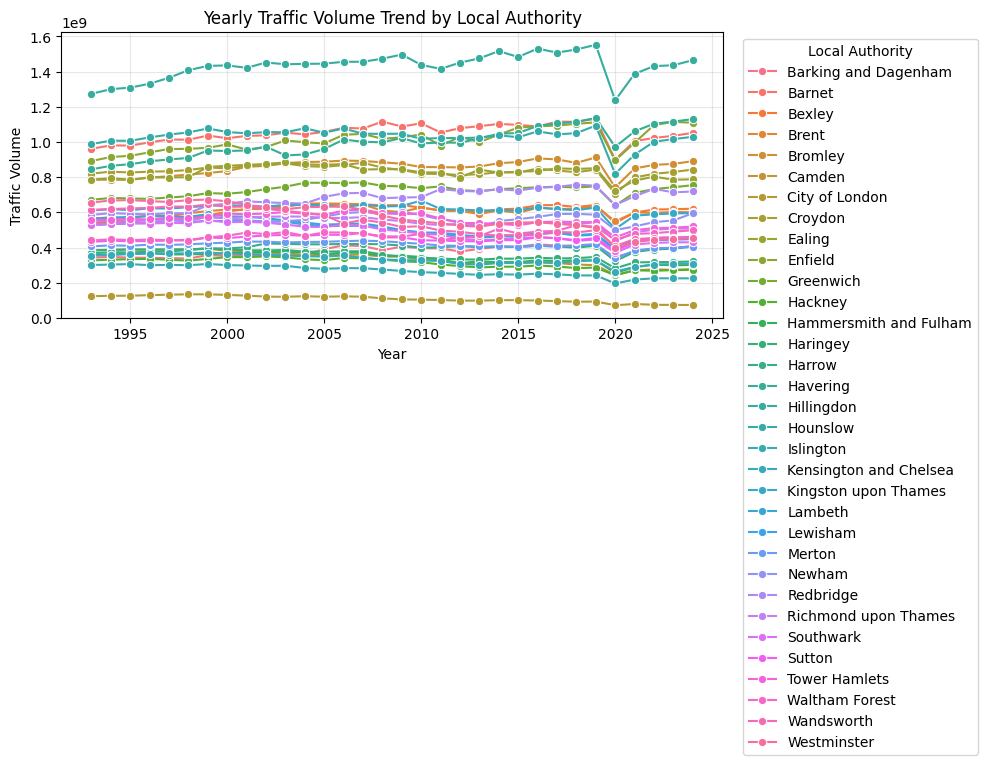

In [ ]:
#PHASE 2A: Multi-authority trend charts
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(10,6))
sns.lineplot(
    data=df_la_london.sort_values(['local_authority_name','year']),
    x='year', y='all_motor_vehicles', hue='local_authority_name', marker='o'
)
plt.title('Yearly Traffic Volume Trend by Local Authority')
plt.xlabel('Year'); plt.ylabel('Traffic Volume'); plt.grid(True, alpha=0.3)
plt.legend(title='Local Authority', bbox_to_anchor=(1.02,1), loc='upper left', ncol=1)
plt.tight_layout(); plt.show()

In [ ]:
# Interactive trend with YoY %
import plotly.express as px
df_trend = (df_la_london
            .sort_values(['local_authority_name','year'])
            .assign(yoy_pct=lambda d: 100*(d['all_motor_vehicles']/
                                           d.groupby('local_authority_name')['all_motor_vehicles'].shift(1) - 1)))

fig = px.line(df_trend, x='year', y='all_motor_vehicles', color='local_authority_name',
              markers=True, title='Traffic Trend by Local Authority (Interactive)',
              labels={'all_motor_vehicles':'Traffic Volume','year':'Year'})

fig.update_traces(
    hovertemplate="<b>%{fullData.name}</b><br>Year: %{x}<br>Traffic: %{y:,.0f}<br>YoY: %{customdata:.1f}%<extra></extra>",
    customdata=df_trend['yoy_pct']
)
fig.update_layout(legend_title_text='Local Authority', hovermode='x unified', template='plotly_white')
fig.show()

In [ ]:
#PHASE 2B: True hotspot map (AADF, clustered)
#Load and merge DfT AADF file
aadf = pd.read_csv(data_folder + "average_annual_daily_flow.csv", low_memory=False)

aadf["count_point_id"] = pd.to_numeric(aadf["count_point_id"], errors="coerce")
cp_with_road["count_point_id"] = pd.to_numeric(cp_with_road["count_point_id"], errors="coerce")
aadf["year"] = pd.to_numeric(aadf["year"], errors="coerce")

# Speed up by keeping only relevant IDs
aadf = aadf[aadf["count_point_id"].isin(cp_with_road["count_point_id"])].copy()

aadf_latest = (
    aadf.dropna(subset=["count_point_id", "year"])
        .sort_values("year")
        .groupby("count_point_id", as_index=False)
        .tail(1)[["count_point_id", "all_motor_vehicles"]]
        .rename(columns={"all_motor_vehicles": "AADF"})
)

cp_with_road = cp_with_road.merge(aadf_latest, on="count_point_id", how="left")

print("AADF rows:", aadf_latest.shape)
print("cp_with_road rows:", cp_with_road.shape)
print("Matched (non-null AADF):", cp_with_road["AADF"].notna().sum())
print("Unmatched (null AADF):", cp_with_road["AADF"].isna().sum())

AADF rows: (2734, 2)
cp_with_road rows: (9984, 23)
Matched (non-null AADF): 9984
Unmatched (null AADF): 0


In [ ]:
import folium
from folium.plugins import MarkerCluster
aadf_col = 'AADF'

m = folium.Map(location=[51.5074, -0.1278], zoom_start=10)
cluster = MarkerCluster().add_to(m)

if aadf_col:
    thr = cp_with_road[aadf_col].quantile(0.9)
    top_hotspots = cp_with_road[cp_with_road[aadf_col] >= thr].copy()
    for _, row in top_hotspots.iterrows():
        val = row[aadf_col]
        radius = min(25, max(4, val / (thr/6))) # scale radius
        color = 'red' if val > 1.2*thr else 'orange'
        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=radius, color=color, fill=True, fill_opacity=0.7,
            popup=f"{aadf_col}: {val:,.0f}"
        ).add_to(cluster)
else:
    for _, row in cp_with_road.iterrows():
        folium.CircleMarker(
            location=[row.geometry.y, row.geometry.x],
            radius=3, color='red', fill=True, fill_opacity=0.6
        ).add_to(cluster)

m  # display in Colab

H1: t=-9.637, p=5.557e-11; Wilcoxon W=0, p=5.386e-07; Median %Δ=-18.1%, n=33
Conclusion: Significant decrease (supports H1)
H2: Median post-2021 slope = 6620000.00 vehicles/year across 33 boroughs
Conclusion: Positive recovery (supports H2)


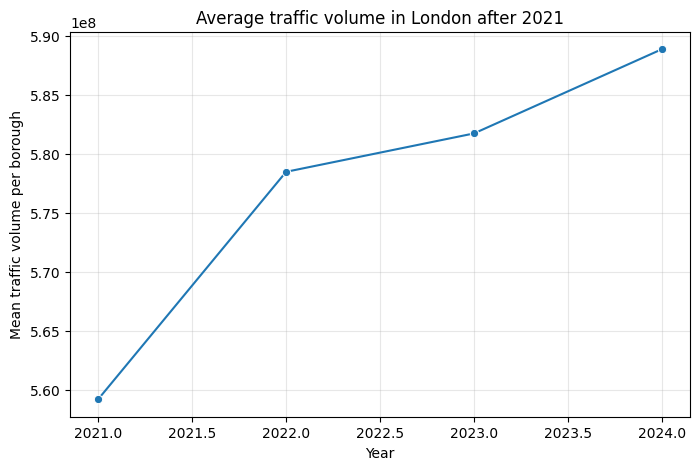

H3: Top 20% boroughs share = 38.7% (latest year = 2024)
Conclusion: Not concentrated (<=50%)


In [ ]:
#PHASE 2C: Non-predictive hypotheses (tests)
# H1: 2019 vs 2020 (paired tests across boroughs)
import numpy as np, pandas as pd
from scipy import stats

df = df_la_london.copy()
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df = df.dropna(subset=['local_authority_name','year','all_motor_vehicles'])

base_year, shock_year = 2019, 2020
la_2019 = (df.query('year == @base_year')
           .groupby('local_authority_name', as_index=False)['all_motor_vehicles'].sum()
           .rename(columns={'all_motor_vehicles': f'vol_{base_year}'}))
la_2020 = (df.query('year == @shock_year')
           .groupby('local_authority_name', as_index=False)['all_motor_vehicles'].sum()
           .rename(columns={'all_motor_vehicles': f'vol_{shock_year}'}))

paired = pd.merge(la_2019, la_2020, on='local_authority_name', how='inner')
t_stat, t_p = stats.ttest_rel(paired[f'vol_{shock_year}'], paired[f'vol_{base_year}'])
w_stat, w_p = stats.wilcoxon(paired[f'vol_{shock_year}'], paired[f'vol_{base_year}'])
paired['pct_change'] = 100 * (paired[f'vol_{shock_year}'] -
                             paired[f'vol_{base_year}']) / paired[f'vol_{base_year}']

print(f"H1: t={t_stat:.3f}, p={t_p:.4g}; Wilcoxon W={w_stat:.0f}, p={w_p:.4g}; "
      f"Median %Δ={paired['pct_change'].median():.1f}%, n={len(paired)}")
print("Conclusion:", "Significant decrease (supports H1)" if (t_p<0.05 or w_p<0.05)
      else "No significant decrease")

# H2: Post-2021 recovery trend (median slope across boroughs)
import statsmodels.api as sm
import numpy as np
df_tr = df_la_london.copy()
df_tr['year'] = pd.to_numeric(df_tr['year'], errors='coerce')
df_tr = df_tr.dropna(subset=['year','all_motor_vehicles','local_authority_name'])
df_tr = df_tr.query('year >= 2021')
slopes = []
for la, grp in df_tr.groupby('local_authority_name'):
    if grp['year'].nunique() >= 3: # need enough points
        X = sm.add_constant(grp['year'])
        y = grp['all_motor_vehicles']
        res = sm.OLS(y, X).fit()
        slopes.append(res.params['year'])
median_slope = np.median(slopes) if slopes else np.nan
print(f"H2: Median post-2021 slope = {median_slope:.2f} vehicles/year across {len(slopes)} boroughs")
print("Conclusion:", "Positive recovery (supports H2)" if (median_slope>0) else "No positive median trend")

# Mean traffic per year across boroughs
yearly_mean = (
    df_tr.groupby('year')['all_motor_vehicles']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))
sns.lineplot(data=yearly_mean, x='year', y='all_motor_vehicles', marker='o')
plt.title("Average traffic volume in London after 2021")
plt.xlabel("Year")
plt.ylabel("Mean traffic volume per borough")
plt.grid(True, alpha=0.3)
plt.show()

# H3: Pareto concentration at latest year
import numpy as np, pandas as pd
df = df_la_london.copy()
df['year'] = pd.to_numeric(df['year'], errors='coerce')
latest = df['year'].max()
totals = (df.query('year == @latest')
 .groupby('local_authority_name', as_index=False)['all_motor_vehicles'].sum()
 .rename(columns={'all_motor_vehicles':'total'}))
k = max(1, int(np.ceil(0.2 * len(totals)))) # top 20%
share = totals.nlargest(k, 'total')['total'].sum() / totals['total'].sum()
print(f"H3: Top 20% boroughs share = {share*100:.1f}% (latest year = {latest})")
print("Conclusion:", "Concentrated (>50%)" if share > 0.5 else "Not concentrated (<=50%)")

PHASE 3: Feature engineering

In [ ]:
df_fe = df_la_london.copy()
df_fe['year'] = pd.to_numeric(df_fe['year'], errors='coerce')
df_fe = df_fe.dropna(subset=['local_authority_name','year','all_motor_vehicles'])

df_fe = df_fe.sort_values(['local_authority_name','year'])
df_fe['lag_1'] = df_fe.groupby('local_authority_name')['all_motor_vehicles'].shift(1)
df_fe['lag_2'] = df_fe.groupby('local_authority_name')['all_motor_vehicles'].shift(2)

# Drop insufficient history
df_fe = df_fe.dropna(subset=['lag_1','lag_2']).reset_index(drop=True)

# One-hot encode borough (keep original name in df_fe for reporting)
df_enc = pd.get_dummies(df_fe, columns=['local_authority_name'], drop_first=True)

feature_cols = ['year','lag_1','lag_2'] + [c for c in df_enc.columns if c.startswith('local_authority_name_')]
X = df_enc[feature_cols]
y = df_enc['all_motor_vehicles']

print("Features:", feature_cols[:6], "... (total:", len(feature_cols), ")")
print("X, y shapes:", X.shape, y.shape)

Features: ['year', 'lag_1', 'lag_2', 'local_authority_name_Barnet', 'local_authority_name_Bexley', 'local_authority_name_Brent'] ... (total: 35 )
X, y shapes: (990, 35) (990,)


PHASE 4 (Models)

In [ ]:
#PHASE 4A: Time-aware split & naive baseline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

latest_year = df_enc['year'].max()
train_mask = df_enc['year'] < latest_year
test_mask  = df_enc['year'] == latest_year

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

# Naive baseline: predict next year = last year's value (lag_1)
y_pred_naive = df_enc.loc[test_mask, 'lag_1']
print("Naive Lag-1 baseline:",
      "MAE", mean_absolute_error(y_test, y_pred_naive),
      "RMSE", mean_squared_error(y_test, y_pred_naive)**0.5,
      "R²", r2_score(y_test, y_pred_naive))

# MAPE/sMAPE + uncertainty bands
def smape(y_true, y_pred):
    """Symmetric MAPE (%) — robust for large scales."""
    return 100 * np.mean(
        2.0 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-12)
    )

def mape(y_true, y_pred):
    """Classical MAPE (%) — use with care if y_true has zeros."""
    return 100 * np.mean(np.abs((y_true - y_pred) / (y_true + 1e-12)))

Naive Lag-1 baseline: MAE 7890909.090909091 RMSE 11765202.930676546 R² 0.9984981992726484


In [ ]:
#PHASE 4B: Train RF & XGBoost, evaluate
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

def eval_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    print(f"{name}: MAE={mae:.2f} | RMSE={rmse:.2f} | R²={r2:.3f}")
    return mae, rmse, r2

rf = RandomForestRegressor(
    n_estimators=600,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_scores = eval_model("RandomForest (latest-year test)", y_test, rf_pred)

xgb = XGBRegressor(
    n_estimators=800, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    random_state=42, n_jobs=-1, tree_method="hist"
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_scores = eval_model("XGBoost (latest-year test)", y_test, xgb_pred)

RandomForest (latest-year test): MAE=18141754.90 | RMSE=26729542.26 | R²=0.992
XGBoost (latest-year test): MAE=7112814.06 | RMSE=10091880.21 | R²=0.999


In [ ]:

!pip -q install lightgbm


In [ ]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
     verbosity=-1,   # suppress logs
        verbose=-1      # suppress logs
)

lgbm.fit(X_train, y_train)
lgbm_pred = lgbm.predict(X_test)

eval_model("LightGBM (latest-year test)", y_test, lgbm_pred)


LightGBM (latest-year test): MAE=11200814.69 | RMSE=16146654.05 | R²=0.997


(11200814.692919968, 16146654.054392591, 0.9971713543465808)

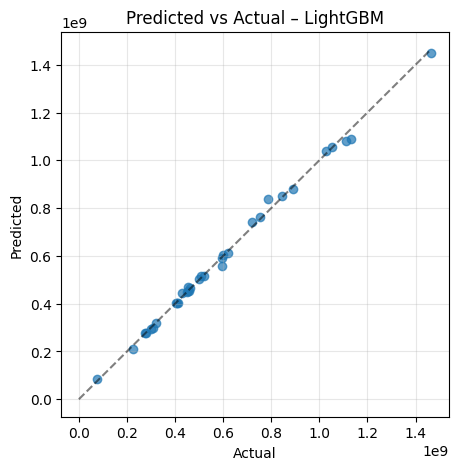

In [ ]:
# Train LightGBM Model, evaluate
plt.figure(figsize=(5,5))
plt.scatter(y_test, lgbm_pred, alpha=0.7)
mx = max(y_test.max(), lgbm_pred.max())
plt.plot([0,mx], [0,mx], 'k--', alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual – LightGBM")
plt.grid(alpha=0.3)
plt.show()


In [ ]:
#PHASE 4D: TimeSeries CV
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

def ts_cv_scores(model, X_df, y_series, years, splits=3):
    order = np.argsort(years.values)
    Xo, yo, yo_years = X_df.iloc[order], y_series.iloc[order], years.iloc[order]
    tscv = TimeSeriesSplit(n_splits=splits)
    out = []
    for k, (tr, te) in enumerate(tscv.split(Xo)):
        model.fit(Xo.iloc[tr], yo.iloc[tr])
        pred = model.predict(Xo.iloc[te])
        mae  = mean_absolute_error(yo.iloc[te], pred)
        rmse = mean_squared_error(yo.iloc[te], pred)**0.5
        r2   = r2_score(yo.iloc[te], pred)
        yr_train = (yo_years.iloc[tr].min(), yo_years.iloc[tr].max())
        yr_test  = (yo_years.iloc[te].min(), yo_years.iloc[te].max())
        print(f"Fold {k}: Train {yr_train} -> Test {yr_test} | MAE={mae:.2f} RMSE={rmse:.2f} R²={r2:.3f}")
        out.append((k, yr_train, yr_test, mae, rmse, r2))
    return out

print("\nTimeSeries CV — RandomForest")
_ = ts_cv_scores(RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1, min_samples_leaf=2),
                 X, y, df_enc['year'])

print("\nTimeSeries CV — XGBoost")
_ = ts_cv_scores(XGBRegressor(n_estimators=400, learning_rate=0.1, max_depth=6,
                              subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, tree_method="hist"),
                 X, y, df_enc['year'])
print("\nTimeSeries CV — LightGBM")
_ = ts_cv_scores(
    LGBMRegressor(
        n_estimators=400,
        learning_rate=0.1,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=-1,   # suppress logs
        verbose=-1      # suppress logs
    ),
    X, y, df_enc['year']
)




TimeSeries CV — RandomForest
Fold 0: Train (1995, 2002) -> Test (2002, 2010) | MAE=15325122.89 RMSE=20579946.43 R²=0.995
Fold 1: Train (1995, 2010) -> Test (2010, 2017) | MAE=13777603.29 RMSE=17689651.09 R²=0.996
Fold 2: Train (1995, 2017) -> Test (2017, 2024) | MAE=30113572.79 RMSE=49327073.56 R²=0.972

TimeSeries CV — XGBoost
Fold 0: Train (1995, 2002) -> Test (2002, 2010) | MAE=17660577.30 RMSE=27800774.82 R²=0.990
Fold 1: Train (1995, 2010) -> Test (2010, 2017) | MAE=17477989.51 RMSE=27839593.33 R²=0.991
Fold 2: Train (1995, 2017) -> Test (2017, 2024) | MAE=26993164.15 RMSE=49932392.89 R²=0.971

TimeSeries CV — LightGBM
Fold 0: Train (1995, 2002) -> Test (2002, 2010) | MAE=34833531.08 RMSE=71790019.50 R²=0.934
Fold 1: Train (1995, 2010) -> Test (2010, 2017) | MAE=31212321.96 RMSE=56769302.05 R²=0.963
Fold 2: Train (1995, 2017) -> Test (2017, 2024) | MAE=28751599.91 RMSE=51328878.68 R²=0.969


In [ ]:
# Walk‑forward CV (year‑by‑year) for business realism

import numpy as np

def walk_forward_scores(model, X_df, y_series, years_series):
    """Train on all past years; test on the next single year, iterating across the timeline."""
    years_sorted = np.array(sorted(years_series.unique()))
    results = []  # list of (test_year, MAE, RMSE, R2, sMAPE)
    for t_year in years_sorted[3:]:  # start after you have enough history
        train_idx = years_series < t_year
        test_idx  = years_series == t_year
        if test_idx.sum() == 0 or train_idx.sum() < 50:
            continue

        model.fit(X_df[train_idx], y_series[train_idx])
        y_pred = model.predict(X_df[test_idx])

        mae  = mean_absolute_error(y_series[test_idx], y_pred)
        rmse = np.sqrt(mean_squared_error(y_series[test_idx], y_pred))
        r2   = r2_score(y_series[test_idx], y_pred)
        s    = smape(y_series[test_idx], y_pred)

        results.append((int(t_year), mae, rmse, r2, s))

    return results

# Example: run with the best-performing model (XGBoost)
wf_results = walk_forward_scores(
    XGBRegressor(n_estimators=800, max_depth=6, learning_rate=0.05,
                 subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                 random_state=42, n_jobs=-1, tree_method="hist"),
    X, y, df_enc['year']
)

# Print a compact summary
print("\nWalk-forward CV (train past → test next year):")
for (yr, mae, rmse, r2, s) in wf_results:
    print(f"  Year {yr}: MAE={mae:,.0f} | RMSE={rmse:,.0f} | R²={r2:.3f} | sMAPE={s:.2f}%")

# Aggregate metrics for executive reporting
if wf_results:
    arr = np.array(wf_results)
    avg_sMAPE = arr[:,4].mean()
    print(f"\nAverage walk-forward sMAPE: {avg_sMAPE:.2f}%")



Walk-forward CV (train past → test next year):
  Year 1998: MAE=7,494,278 | RMSE=12,565,335 | R²=0.998 | sMAPE=1.36%
  Year 1999: MAE=14,812,233 | RMSE=19,577,523 | R²=0.995 | sMAPE=2.49%
  Year 2000: MAE=9,148,868 | RMSE=10,685,849 | R²=0.998 | sMAPE=1.64%
  Year 2001: MAE=9,887,599 | RMSE=12,334,970 | R²=0.998 | sMAPE=1.71%
  Year 2002: MAE=11,606,096 | RMSE=23,265,472 | R²=0.993 | sMAPE=2.87%
  Year 2003: MAE=14,288,651 | RMSE=29,057,737 | R²=0.988 | sMAPE=3.47%
  Year 2004: MAE=9,210,430 | RMSE=11,199,615 | R²=0.998 | sMAPE=1.61%
  Year 2005: MAE=11,516,750 | RMSE=16,377,300 | R²=0.996 | sMAPE=2.18%
  Year 2006: MAE=15,931,132 | RMSE=22,926,705 | R²=0.993 | sMAPE=2.71%
  Year 2007: MAE=9,146,361 | RMSE=13,136,394 | R²=0.998 | sMAPE=1.54%
  Year 2008: MAE=18,694,859 | RMSE=21,970,025 | R²=0.994 | sMAPE=3.43%
  Year 2009: MAE=12,138,272 | RMSE=15,048,868 | R²=0.997 | sMAPE=2.42%
  Year 2010: MAE=13,545,559 | RMSE=19,485,780 | R²=0.995 | sMAPE=1.97%
  Year 2011: MAE=14,267,720 | RMSE


sMAPE / MAPE (latest-year test):
  RandomForest: sMAPE=2.96% | MAPE=2.91%
  XGBoost     : sMAPE=1.20% | MAPE=1.20%
  LightGBM    : sMAPE=2.27% | MAPE=2.30%


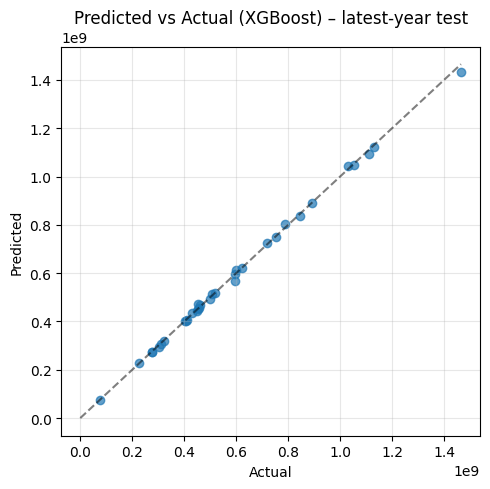

In [ ]:
#PHASE 4E: Error analysis & parity plot
import matplotlib.pyplot as plt

res = df_enc.loc[test_mask, ['year']].copy()
# Recover borough names from df_fe by aligned index
res['borough']  = df_fe.loc[test_mask, 'local_authority_name'].values
res['actual']   = y_test.values
res['rf_pred']  = rf_pred
res['xgb_pred'] = xgb_pred

print("\nsMAPE / MAPE (latest-year test):")
print(f"  RandomForest: sMAPE={smape(y_test, rf_pred):.2f}% | MAPE={mape(y_test, rf_pred):.2f}%")
print(f"  XGBoost     : sMAPE={smape(y_test, xgb_pred):.2f}% | MAPE={mape(y_test, xgb_pred):.2f}%")
print(f"  LightGBM    : sMAPE={smape(y_test, lgbm_pred):.2f}% | MAPE={mape(y_test, lgbm_pred):.2f}%")

# Pred vs Actual (XGB)
plt.figure(figsize=(5,5))
plt.scatter(res['actual'], res['xgb_pred'], alpha=0.7)
mx = max(res['actual'].max(), res['xgb_pred'].max())
plt.plot([0,mx],[0,mx],'k--',alpha=0.5)
plt.title('Predicted vs Actual (XGBoost) – latest-year test')
plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

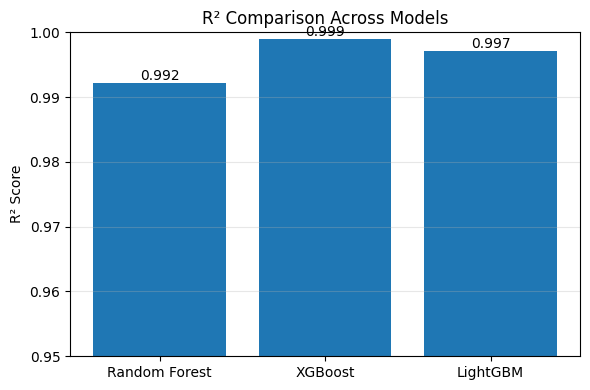

In [ ]:
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Compute R² scores
r2_scores = {
    "Random Forest": r2_score(y_test, rf_pred),
    "XGBoost": r2_score(y_test, xgb_pred),
    "LightGBM": r2_score(y_test, lgbm_pred)
}

# Plot
plt.figure(figsize=(6,4))
plt.bar(r2_scores.keys(), r2_scores.values())
plt.title("R² Comparison Across Models")
plt.ylabel("R² Score")
plt.ylim(0.95, 1.0)
plt.grid(axis='y', alpha=0.3)

# Annotate values
for i, v in enumerate(r2_scores.values()):
    plt.text(i, v, f"{v:.3f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()


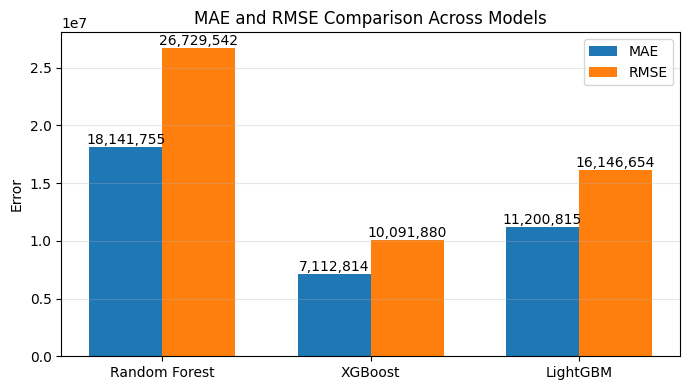

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Compute MAE & RMSE safely
metrics = {
    "Random Forest": {
        "MAE": mean_absolute_error(y_test, rf_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, rf_pred))
    },
    "XGBoost": {
        "MAE": mean_absolute_error(y_test, xgb_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, xgb_pred))
    },
    "LightGBM": {
        "MAE": mean_absolute_error(y_test, lgbm_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, lgbm_pred))
    }
}

models = list(metrics.keys())
mae_vals = [metrics[m]["MAE"] for m in models]
rmse_vals = [metrics[m]["RMSE"] for m in models]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(7,4))
plt.bar(x - width/2, mae_vals, width, label='MAE')
plt.bar(x + width/2, rmse_vals, width, label='RMSE')

plt.xticks(x, models)
plt.ylabel("Error")
plt.title("MAE and RMSE Comparison Across Models")
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Value labels
for i in range(len(models)):
    plt.text(x[i] - width/2, mae_vals[i], f"{mae_vals[i]:,.0f}", ha='center', va='bottom')
    plt.text(x[i] + width/2, rmse_vals[i], f"{rmse_vals[i]:,.0f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [ ]:
#PHASE 4F: SHAP explainability (TreeSHAP)
import shap
import numpy as np
import matplotlib.pyplot as plt

# sample for speed
rng = np.random.RandomState(42)
sample_idx = rng.choice(X_train.index, size=min(2000, len(X_train)), replace=False)
X_shap = X_train.loc[sample_idx]

explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_shap)


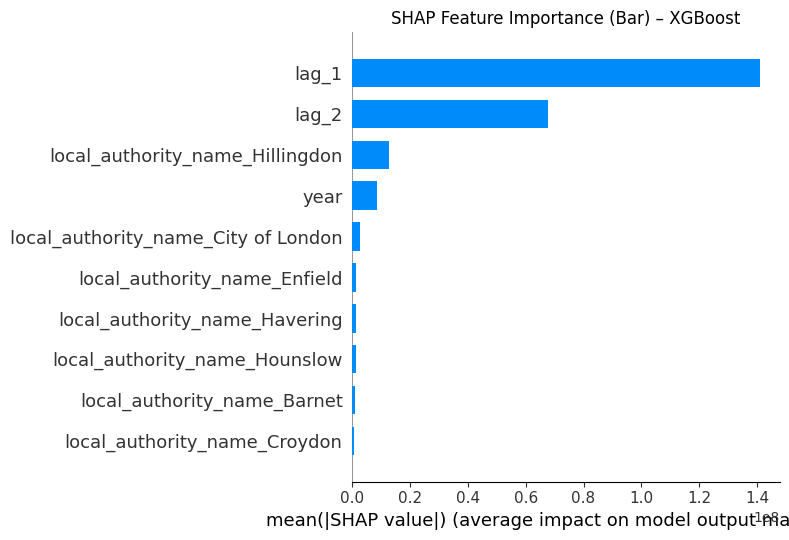

In [ ]:
#Summary bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_xgb, X_shap, plot_type="bar", max_display=10, show=False)
plt.title("SHAP Feature Importance (Bar) – XGBoost")
plt.tight_layout()
plt.show()

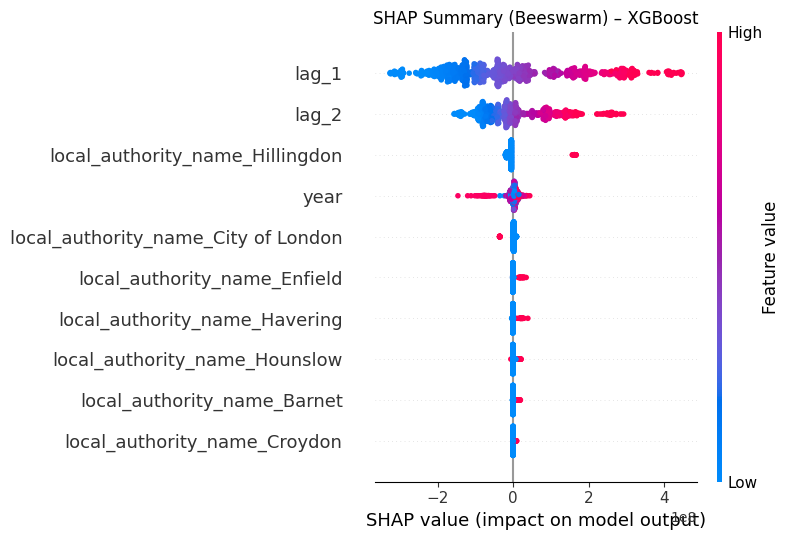

In [ ]:
#Beeswarm summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_xgb, X_shap, max_display=10, show=False)
plt.title("SHAP Summary (Beeswarm) – XGBoost")
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

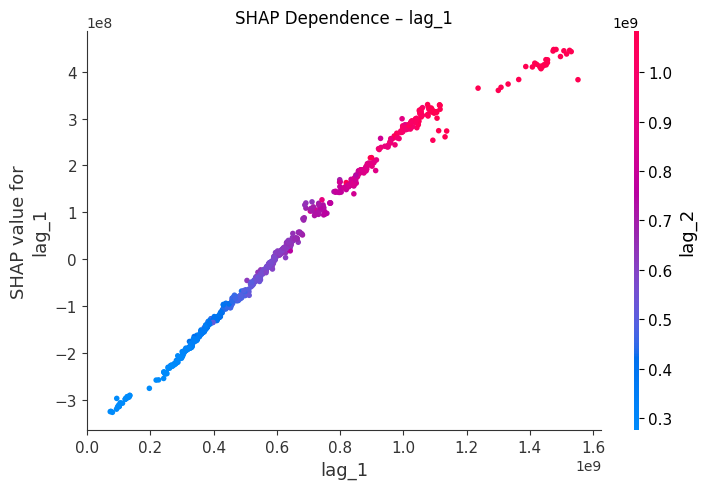

<Figure size 800x600 with 0 Axes>

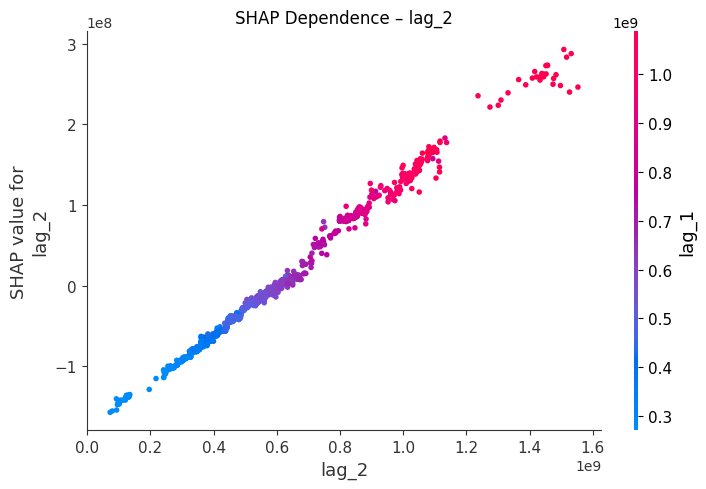

<Figure size 800x600 with 0 Axes>

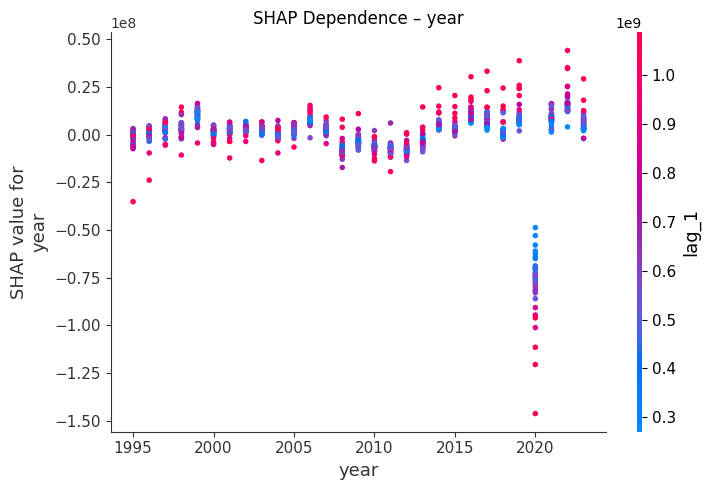

In [ ]:
#Dependence plots
for feat in ["lag_1", "lag_2", "year"]:
    if feat in X_shap.columns:
        plt.figure(figsize=(8, 6))
        shap.dependence_plot(feat, shap_values_xgb, X_shap, show=False)
        plt.title(f"SHAP Dependence – {feat}")
        plt.tight_layout()
        plt.show()
        plt.close()

Make the files Power BI–ready

In [ ]:
#Export the GeoPackage to CSV (points) and GeoJSON (reference layer)

# Convert count_points_london_with_roads.gpkg → CSV + GeoJSON for Power BI
import geopandas as gpd

IN_GPKG = '/content/drive/MyDrive/Datasets/Processed/count_points_london_with_roads.gpkg'
OUT_DIR = '/content/drive/MyDrive/Datasets/Processed/PowerBI/'
import os; os.makedirs(OUT_DIR, exist_ok=True)

gdf = gpd.read_file(IN_GPKG)          # CRS is EPSG:4326 from your pipeline
gdf = gdf.to_crs(4326)                # ensure lat/lon
gdf['latitude']  = gdf.geometry.y
gdf['longitude'] = gdf.geometry.x

# Keep light, analysis-friendly columns
keep = [c for c in gdf.columns if c not in ['geometry']]
gdf[keep].to_csv(OUT_DIR + 'count_points_with_roads_for_pbi.csv', index=False)

# Also export a reference layer for Azure Maps (e.g., road lines or points)
gdf[['road_type','road_name','latitude','longitude']].to_json(OUT_DIR + 'points_reference.geojson', orient='records')
print('Saved:',
      OUT_DIR + 'count_points_with_roads_for_pbi.csv',
      'and',
      OUT_DIR + 'points_reference.geojson')

Saved: /content/drive/MyDrive/Datasets/Processed/PowerBI/count_points_with_roads_for_pbi.csv and /content/drive/MyDrive/Datasets/Processed/PowerBI/points_reference.geojson


For Dashboard

In [ ]:
print(X_test.columns.tolist())

['year', 'lag_1', 'lag_2', 'local_authority_name_Barnet', 'local_authority_name_Bexley', 'local_authority_name_Brent', 'local_authority_name_Bromley', 'local_authority_name_Camden', 'local_authority_name_City of London', 'local_authority_name_Croydon', 'local_authority_name_Ealing', 'local_authority_name_Enfield', 'local_authority_name_Greenwich', 'local_authority_name_Hackney', 'local_authority_name_Hammersmith and Fulham', 'local_authority_name_Haringey', 'local_authority_name_Harrow', 'local_authority_name_Havering', 'local_authority_name_Hillingdon', 'local_authority_name_Hounslow', 'local_authority_name_Islington', 'local_authority_name_Kensington and Chelsea', 'local_authority_name_Kingston upon Thames', 'local_authority_name_Lambeth', 'local_authority_name_Lewisham', 'local_authority_name_Merton', 'local_authority_name_Newham', 'local_authority_name_Redbridge', 'local_authority_name_Richmond upon Thames', 'local_authority_name_Southwark', 'local_authority_name_Sutton', 'local_au

In [ ]:
#Fresh mount to avoid stale sessions
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

from pathlib import Path
import os, pandas as pd


TARGET_DIR = Path('/content/drive/MyDrive/Datasets/Processed/PowerBI')
TARGET_DIR.mkdir(parents=True, exist_ok=True)

print("Target folder:", TARGET_DIR)
print("Exists:", TARGET_DIR.exists())

# 2) Write a tiny 'ping' file to prove we can write here.
ping_file = TARGET_DIR / 'ping.txt'
with open(ping_file, 'w') as f:
    f.write('hello from colab')

print("Ping exists:", ping_file.exists(), "| Size:", ping_file.stat().st_size if ping_file.exists() else "NA")

# 3) List the folder contents (should show ping.txt afterwards)
print("\nFolder listing after write:")
for p in sorted(TARGET_DIR.glob('*')):
    print(" -", p.name)

Mounted at /content/drive
Target folder: /content/drive/MyDrive/Datasets/Processed/PowerBI
Exists: True
Ping exists: True | Size: 16

Folder listing after write:
 - Fact_AADF.csv
 - Fact_BoroughYear.csv
 - Fact_MLResults.csv
 - Fact_MLResults_20251218_001822.csv
 - Fact_MLResults_Full.csv
 - count_points_with_roads_for_pbi.csv
 - ping.txt
 - points_reference.geojson
 - traffic_borough_year_ml.csv


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Paths (Colab / Google Drive style)
TARGET_DIR = Path('/content/drive/MyDrive/Datasets/Processed/PowerBI')
AADF_SRC    = Path('/content/drive/MyDrive/Datasets/average_annual_daily_flow.csv')
BOROUGH_SRC = Path('/content/drive/MyDrive/Datasets/Processed/local_authority_traffic_london.csv')

TARGET_DIR.mkdir(parents=True, exist_ok=True)

print("Source exists:")
print("  AADF   :", AADF_SRC.exists(), AADF_SRC)
print("  Borough:", BOROUGH_SRC.exists(), BOROUGH_SRC)

missing = [p for p in [AADF_SRC, BOROUGH_SRC] if not p.exists()]
if missing:
    raise FileNotFoundError(f"Missing source(s): {missing}")

# Helper functions
def to_int64(df, col):
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')
    return df

def to_float(df, col):
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').astype('float')
    return df

def normalize_borough_column(df):
    if 'borough' not in df.columns:
        if 'local_authority_name' in df.columns:
            df['borough'] = df['local_authority_name']
        elif 'local_authority' in df.columns:
            df['borough'] = df['local_authority']
        else:
            raise KeyError("Could not find a borough name column")
    return df

def show_years(label, df):
    if 'year' in df.columns:
        yrs = list(pd.Series(df['year'].dropna().unique()).sort_values())
        print(f"[{label}] years ({len(yrs)}):", yrs[:20], "..." if len(yrs) > 20 else "")
    else:
        print(f"[{label}] no 'year' column")

# Load and prep AADF
aadf = pd.read_csv(AADF_SRC, low_memory=False)
for c in ['year','latitude','longitude','all_motor_vehicles']:
    aadf = to_float(aadf, c)
aadf['year'] = pd.to_numeric(aadf['year'], errors='coerce').astype('Int64')

LONDON = [
 'Barnet','Hillingdon','Tower Hamlets','Islington','Southwark','Lewisham','Greenwich',
 'Bexley','Lambeth','Wandsworth','Westminster','Kensington and Chelsea','Hounslow','Brent',
 'Enfield','Hackney','Redbridge','Waltham Forest','Croydon','Camden','Hammersmith and Fulham',
 'Ealing','Haringey','Newham','Barking and Dagenham','City of London','Richmond upon Thames',
 'Bromley','Sutton','Kingston upon Thames','Harrow','Havering','Merton'
]
aadf = aadf[aadf['local_authority_name'].isin(LONDON)].copy()
aadf_latest = (
    aadf.dropna(subset=['count_point_id','year'])
        .sort_values(['count_point_id','year'])
        .groupby('count_point_id', as_index=False)
        .tail(1)[[
            'count_point_id','local_authority_name','road_name','road_category','road_type',
            'latitude','longitude','all_motor_vehicles','year',
            'estimation_method','estimation_method_detailed'
        ]]
        .rename(columns={'all_motor_vehicles':'AADF'})
)
show_years("aadf_latest", aadf_latest)

# Load borough year master
borough = pd.read_csv(BOROUGH_SRC, low_memory=False)
borough = normalize_borough_column(borough)
borough = to_int64(borough, 'year')
borough = borough[borough['borough'].isin(LONDON)].copy()
by_calendar = (
    borough[['borough','year']]
    .dropna(subset=['borough','year'])
    .drop_duplicates()
    .sort_values(['borough','year'])
)
show_years("borough", borough)

# ML Predictions (updated logic)
df_fe = by_calendar.copy()

# Use actual values from borough if available
if 'all_motor_vehicles' in borough.columns:
    df_fe = df_fe.merge(borough[['borough','year','all_motor_vehicles']], on=['borough','year'], how='left')
else:
    df_fe['all_motor_vehicles'] = 0  # placeholder

# Create lags
df_fe['lag_1'] = df_fe.groupby('borough')['all_motor_vehicles'].shift(1).fillna(0)
df_fe['lag_2'] = df_fe.groupby('borough')['all_motor_vehicles'].shift(2).fillna(0)

# One-hot encode borough
df_enc = pd.get_dummies(df_fe, columns=['borough'], drop_first=True)
feature_cols = ['year','lag_1','lag_2'] + [c for c in df_enc.columns if c.startswith('borough_')]
X_full = df_enc[feature_cols]
y_full = df_fe['all_motor_vehicles']

# Train models
rf = RandomForestRegressor(n_estimators=600, min_samples_leaf=2, random_state=42, n_jobs=-1)
xgb = XGBRegressor(n_estimators=800, max_depth=6, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                   random_state=42, n_jobs=-1, tree_method="hist")
lgbm = LGBMRegressor(n_estimators=600, learning_rate=0.05,
                     subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=-1)

rf.fit(X_full, y_full)
xgb.fit(X_full, y_full)
lgbm.fit(X_full, y_full)

# Predict
df_fe['rf_pred'] = rf.predict(X_full)
df_fe['xgb_pred'] = xgb.predict(X_full)
df_fe['lgbm_pred'] = lgbm.predict(X_full)

# Errors
df_fe['rf_error'] = df_fe['all_motor_vehicles'] - df_fe['rf_pred']
df_fe['xgb_error'] = df_fe['all_motor_vehicles'] - df_fe['xgb_pred']
df_fe['lgbm_error'] = df_fe['all_motor_vehicles'] - df_fe['lgbm_pred']

df_fe['rf_abs_error'] = df_fe['rf_error'].abs()
df_fe['xgb_abs_error'] = df_fe['xgb_error'].abs()
df_fe['lgbm_abs_error'] = df_fe['lgbm_error'].abs()

# Reorder columns
cols_order = ['borough','year','all_motor_vehicles','rf_pred','xgb_pred','lgbm_pred',
              'rf_error','xgb_error','lgbm_error','rf_abs_error','xgb_abs_error','lgbm_abs_error']
other_cols = [c for c in df_fe.columns if c not in cols_order]
fact_ml = df_fe[cols_order + other_cols]

# Save outputs
aadf_latest.to_csv(TARGET_DIR / 'Fact_AADF.csv', index=False)
borough.to_csv(TARGET_DIR / 'Fact_BoroughYear.csv', index=False)
fact_ml.to_csv(TARGET_DIR / 'Fact_MLResults.csv', index=False)

print("\n✅ Saved to:", TARGET_DIR)
for name in ['Fact_AADF.csv','Fact_BoroughYear.csv','Fact_MLResults.csv']:
    p = TARGET_DIR / name
    print(" -", name, "| exists:", p.exists(), "| size:", p.stat().st_size if p.exists() else "NA")


Source exists:
  AADF   : True /content/drive/MyDrive/Datasets/average_annual_daily_flow.csv
  Borough: True /content/drive/MyDrive/Datasets/Processed/local_authority_traffic_london.csv
[aadf_latest] years (22): [np.int64(2000), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)] ...
[borough] years (32): [np.int64(1993), np.int64(1994), np.int64(1995), np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012)] ...

✅ Saved to: /content/drive/MyDrive/Datasets/Processed/PowerBI
 - Fact_AADF.csv | exists: True | size: 393759
 - Fac

In [ ]:
import pandas as pd

# Load one of your fact tables
df = pd.read_csv("/content/drive/MyDrive/Outputs/traffic_borough_year_ml.csv")

# Create borough dimension
dim_borough = (
    df[['borough']]
    .drop_duplicates()
    .sort_values('borough')
    .reset_index(drop=True)
)

dim_borough.to_csv("/content/drive/MyDrive/Outputs/Dim_Borough.csv", index=False)

print(dim_borough.head())


                borough
0  Barking and Dagenham
1                Barnet
2                Bexley
3                 Brent
4               Bromley


In [ ]:
# Create year dimension
dim_year = (
    df[['year']]
    .drop_duplicates()
    .sort_values('year')
    .reset_index(drop=True)
)

dim_year.to_csv("/content/drive/MyDrive/Outputs/Dim_Year.csv", index=False)

print(dim_year.head())


   year
0  2024
